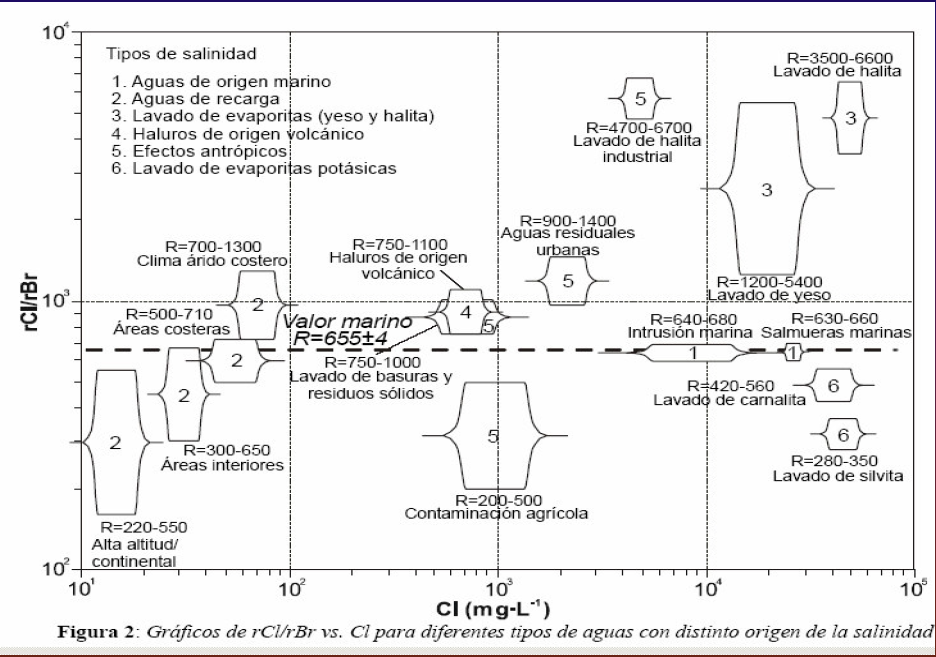

In [11]:
from IPython.display import Image
Image(r"figures/rCl_rBr_vs_Cl_teoria.png")

### **2. Gráficos rCl/rBr vs. Cl **
Según este estudio la relación de rCl/rBr del agua termal se corresponde con valores de "recharge water from continental areas" (See Table 2)\
[Alcala & Custodio,2008](references\2008_Alcala_Custodio.pdf) 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
# ===============================
# 1. Cargar archivo Excel
# ===============================
file = r"C:/Rosi/THERMECOWAT/Pruebas_graficos_Cl.xlsx"
df = pd.read_excel(file)

# ===============================
# 2. Limpiar Br ("<0.060" → 0.060/2)
# ===============================
def clean_br(value):
    if isinstance(value, str) and "<" in value:
        num = float(value.replace("<", ""))
        return num / 2
    return float(value)

df["Br"] = df["Br"].apply(clean_br)

# ===============================
# 3. Convertir mg/L a mol/L
#    MCl = 35.453 g/mol
#    MBr = 79.904 g/mol
# ===============================

MW_Cl = 35.453   # g/mol
MW_Br = 79.904   # g/mol

df["rCl_molL"] = df["Cl"] / (MW_Cl * 1000)      # mg/L → mol/L
df["rBr_molL"] = df["Br"] / (MW_Br * 1000)

# ===============================
# 4. Calcular rCl/rBr (mol/mol)
# ===============================
df["rCl_rBr"] = df["rCl_molL"] / df["rBr_molL"]

# Mostrar resultados
df_display = df[["Sample", "Cl", "Br", "rCl_molL", "rBr_molL", "rCl_rBr"]]
df_display

,Sample,Cl,Br,rCl_molL,rBr_molL,rCl_rBr
0,CdM_001,518.0,3.380,0.014611,4.230076e-05,345.404976
1,CdM_084,65.3,0.078,0.001842,9.761714e-07,1886.835804
2,CdM_082,59.8,0.090,0.001687,1.126352e-06,1497.525425
3,CdM_073,55.0,0.131,0.001551,1.639467e-06,946.252247
4,CdM_091,520.0,3.380,0.014667,4.230076e-05,346.738586
5,CdM_088,45.6,0.127,0.001286,1.589407e-06,809.238715
6,CdM_093,37.2,0.030,0.001049,3.754505e-07,2794.713000


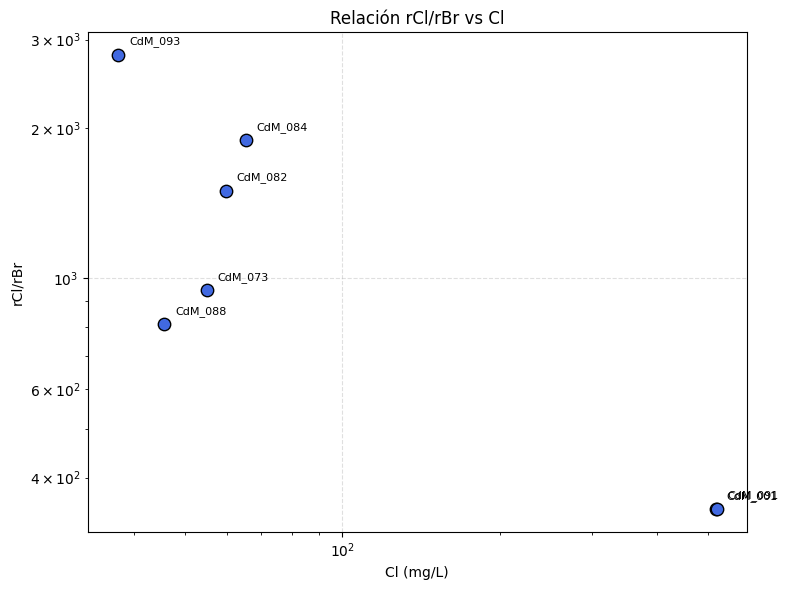

Generado: rCl_rBr_vs_Cl.png


In [6]:
# ===============================
# 5. Graficar rCl/rBr vs Cl
# ===============================
plt.figure(figsize=(8,6))

plt.scatter(df["Cl"], df["rCl_rBr"], s=80, edgecolor="black", color="royalblue")

# Etiquetas con nombre de muestra
for i, row in df.iterrows():
    plt.text(row["Cl"]*1.05, row["rCl_rBr"]*1.05, row["Sample"], fontsize=8)

# Formato log–log
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Cl (mg/L)")
plt.ylabel("rCl/rBr")
plt.title("Relación rCl/rBr vs Cl")

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("rCl_rBr_vs_Cl.png", dpi=300)
plt.show()

print("Generado: rCl_rBr_vs_Cl.png")